# 🤖 Notebook 06: Intelligent Decision-Making Agents

Welcome to the most advanced phase of our multi-agent epidemic simulation! We're now implementing **truly intelligent agents** that can make complex decisions, coordinate with each other, and adapt their strategies based on RAG-powered insights.

**Today's Goals:**
1. **Action-Taking Agents**: Agents that can implement recommendations from the RAG system
2. **Multi-Agent Coordination**: Different types of agencies working together
3. **Dynamic Policy Adjustment**: Real-time policy changes based on simulation conditions
4. **Predictive Analytics**: Using historical data to anticipate future needs
5. **Advanced Visualization**: Dashboard-style monitoring of intelligent agent decisions


In [11]:
# Standard imports
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import json
from typing import List, Dict, Tuple
from dataclasses import dataclass
import warnings
import warnings
warnings.filterwarnings("ignore")

# RAG and ML imports
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# Advanced analytics
from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter

# Enhanced data structures
from dataclasses import dataclass, field
from enum import Enum
from typing import List, Dict, Tuple, Optional
import json

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (16, 12)

print("🚀 Advanced imports loaded - Ready for intelligent agent implementation!")

🚀 Advanced imports loaded - Ready for intelligent agent implementation!


### Policy and Decision Framework

In [13]:
class PolicyType(Enum):
    SOCIAL_DISTANCING = "social_distancing"
    ELECTIVE_SURGERY_BAN = "elective_surgery_ban"
    MASK_MANDATE = "mask_mandate"
    SCHOOL_CLOSURE = "school_closure"
    INTER_HOSPITAL_TRANSFER = "inter_hospital_transfer"
    CRISIS_STANDARDS = "crisis_standards"
    RESOURCE_RATIONING = "resource_rationing"

@dataclass
class Policy:
    policy_type: PolicyType
    active: bool
    effectiveness: float  # 0.0 to 1.0
    implementation_cost: int
    duration_steps: int
    description: str
    
@dataclass
class Decision:
    timestamp: int
    agent_id: str
    decision_type: str
    reasoning: str
    confidence: float
    expected_impact: str
    
@dataclass
class Prediction:
    target_metric: str
    current_value: float
    predicted_value: float
    prediction_horizon: int
    confidence: float

class PolicyManager:
    """Manages all active policies and their effects."""
    
    def __init__(self):
        self.active_policies: Dict[PolicyType, Policy] = {}
        self.policy_history: List[Tuple[int, PolicyType, bool]] = []  # (step, policy, activated)
        
    def activate_policy(self, policy: Policy, step: int):
        """Activate a new policy."""
        self.active_policies[policy.policy_type] = policy
        self.policy_history.append((step, policy.policy_type, True))
        
    def deactivate_policy(self, policy_type: PolicyType, step: int):
        """Deactivate a policy."""
        if policy_type in self.active_policies:
            del self.active_policies[policy_type]
            self.policy_history.append((step, policy_type, False))
    
    def get_transmission_modifier(self):
        """Calculate overall effect on transmission rate."""
        modifier = 1.0
        if PolicyType.SOCIAL_DISTANCING in self.active_policies:
            modifier *= (1 - self.active_policies[PolicyType.SOCIAL_DISTANCING].effectiveness)
        if PolicyType.MASK_MANDATE in self.active_policies:
            modifier *= (1 - self.active_policies[PolicyType.MASK_MANDATE].effectiveness)
        return modifier
    
    def get_hospital_capacity_modifier(self):
        """Calculate effect on hospital capacity."""
        modifier = 1.0
        if PolicyType.ELECTIVE_SURGERY_BAN in self.active_policies:
            modifier += self.active_policies[PolicyType.ELECTIVE_SURGERY_BAN].effectiveness
        return modifier

print("✅ Policy framework and data structures defined")

✅ Policy framework and data structures defined


### Predictive Analytics System

In [12]:
class PredictiveAnalytics:
    """Advanced analytics for predicting epidemic trends."""
    
    def __init__(self):
        self.history_window = 20  # Steps to look back for predictions
        
    def predict_hospital_demand(self, historical_data: pd.DataFrame, horizon: int = 5) -> Prediction:
        """Predict future hospital bed demand."""
        if len(historical_data) < self.history_window:
            return Prediction("hospital_demand", 0, 0, horizon, 0.5)
        
        # Get recent hospital occupancy data
        recent_data = historical_data["Total Hospital Occupancy"].tail(self.history_window).values
        
        # Simple trend analysis using linear regression
        X = np.arange(len(recent_data)).reshape(-1, 1)
        y = recent_data
        
        model = LinearRegression()
        model.fit(X, y)
        
        # Predict future values
        future_X = np.arange(len(recent_data), len(recent_data) + horizon).reshape(-1, 1)
        predictions = model.predict(future_X)
        
        current_value = recent_data[-1]
        predicted_value = predictions[-1]  # Prediction at horizon
        
        # Calculate confidence based on recent trend stability
        recent_changes = np.diff(recent_data)
        volatility = np.std(recent_changes) if len(recent_changes) > 0 else 0
        confidence = max(0.3, 1.0 - volatility / max(1, current_value))
        
        return Prediction("hospital_demand", current_value, predicted_value, horizon, confidence)
    
    def predict_infection_peak(self, historical_data: pd.DataFrame) -> Prediction:
        """Predict when infection numbers will peak."""
        if len(historical_data) < self.history_window:
            return Prediction("infection_peak", 0, 0, 10, 0.5)
        
        infected_total = (historical_data["Infected (Untreated)"] + 
                         historical_data["Hospitalized"]).values
        
        if len(infected_total) < 10:
            return Prediction("infection_peak", infected_total[-1], infected_total[-1], 10, 0.3)
        
        # Smooth the data and find trend
        smoothed = savgol_filter(infected_total, min(11, len(infected_total)), 2)
        
        # Calculate derivatives to find trend changes
        derivatives = np.diff(smoothed)
        
        current_value = infected_total[-1]
        trend = np.mean(derivatives[-5:]) if len(derivatives) >= 5 else 0
        
        # Estimate steps until peak (when derivative becomes negative)
        if trend > 0:
            steps_to_peak = max(5, int(current_value / max(0.1, trend)))
            predicted_peak = current_value + trend * steps_to_peak
        else:
            steps_to_peak = 0
            predicted_peak = current_value
            
        confidence = 0.7 if abs(trend) > 1 else 0.4
        
        return Prediction("infection_peak", current_value, predicted_peak, steps_to_peak, confidence)

print("✅ Predictive analytics system implemented")

✅ Predictive analytics system implemented


### Enhanced Knowledge Base with Action Mapping

In [28]:
# Enhanced knowledge base with actionable policies
enhanced_documents = {
    "actionable_hospital_protocols.txt": """
ACTIONABLE HOSPITAL CAPACITY PROTOCOLS

TRIGGER: Hospital occupancy > 80%
ACTIONS:
- ACTIVATE elective_surgery_ban (effectiveness: 0.25, cost: 100)
- INITIATE inter_hospital_transfer (effectiveness: 0.15, cost: 50)
- ALERT staff for extended shifts

TRIGGER: Hospital occupancy > 90%  
ACTIONS:
- ACTIVATE crisis_standards (effectiveness: 0.20, cost: 200)
- IMPLEMENT resource_rationing (effectiveness: 0.10, cost: 150)
- COORDINATE regional bed sharing

TRIGGER: Predicted demand > capacity in 3 days
ACTIONS:
- PREEMPTIVE elective_surgery_ban (effectiveness: 0.30, cost: 80)
- PREPARE overflow facilities
- REQUEST additional staffing
""",

    "community_intervention_protocols.txt": """
COMMUNITY INTERVENTION PROTOCOLS

TRIGGER: Untreated infected > 100 OR transmission rate > 0.4
ACTIONS:  
- IMPLEMENT social_distancing (effectiveness: 0.35, cost: 300)
- ACTIVATE mask_mandate (effectiveness: 0.20, cost: 100)
- ENHANCE contact tracing

TRIGGER: Hospital occupancy > 85% AND community spread high
ACTIONS:
- IMPLEMENT school_closure (effectiveness: 0.25, cost: 400) 
- LIMIT large gatherings (effectiveness: 0.15, cost: 200)
- INCREASE public messaging

TRIGGER: Predicted peak > hospital capacity
ACTIONS:
- EMERGENCY social_distancing (effectiveness: 0.50, cost: 500)
- MANDATORY mask_mandate (effectiveness: 0.30, cost: 150)
- ACTIVATE emergency response
""",

    "resource_optimization_protocols.txt": """
RESOURCE OPTIMIZATION PROTOCOLS

TRIGGER: Multiple hospitals > 85% capacity
ACTIONS:
- COORDINATE inter_hospital_transfer (effectiveness: 0.25, cost: 100)
- SHARE critical resources (effectiveness: 0.15, cost: 75)
- OPTIMIZE patient distribution

TRIGGER: Predicted ventilator shortage
ACTIONS:
- IMPLEMENT resource_rationing (effectiveness: 0.20, cost: 200)
- PRIORITIZE clinical protocols  
- COORDINATE regional sharing

TRIGGER: Staff shortages predicted
ACTIONS:
- CROSS_TRAIN personnel (effectiveness: 0.15, cost: 100)
- ACTIVATE volunteer programs (effectiveness: 0.10, cost: 50)
- ADJUST shift patterns
"""
}

class EnhancedKnowledgeBase:
    """Knowledge base that can extract actionable policies from documents."""
    
    def __init__(self, documents_path="knowledge_base"):
        self.documents_path = documents_path
        self.vectorstore = None
        self.embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
        self.text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
        
        # Add enhanced documents to our knowledge base
        import os
        os.makedirs(documents_path, exist_ok=True)
        for filename, content in enhanced_documents.items():
            filepath = os.path.join(documents_path, filename)
            with open(filepath, 'w') as f:
                f.write(content)
        
        self.load_and_process_documents()
    
    def load_and_process_documents(self):
        """Load all documents and create vector store."""
        documents = []
        for filename in os.listdir(self.documents_path):
            if filename.endswith('.txt'):
                filepath = os.path.join(self.documents_path, filename)
                with open(filepath, 'r') as f:
                    content = f.read()
                doc = Document(page_content=content, metadata={"source": filename})
                documents.append(doc)
        
        chunks = self.text_splitter.split_documents(documents)
        #print(f"✅ Document chunks created: {len(chunks)} {chunks}")
        self.vectorstore = FAISS.from_documents(chunks, self.embeddings)
        print(f"✅ Enhanced knowledge base loaded with {len(chunks)} chunks")
    
    def search(self, query: str, k: int = 3) -> List[Document]:
        """Perform a similarity search on the vectorstore."""
        if not self.vectorstore:
            return []
        return self.vectorstore.similarity_search(query, k=k)

    
    def extract_actionable_policies(self, situation_description: str, k: int = 3) -> List[Policy]:
        """Extract specific policy recommendations from knowledge base."""
        results = self.vectorstore.similarity_search(situation_description, k=k)
        policies = []
        
        for result in results:
            content = result.page_content
            # Parse content for actionable policies
            if "ACTIONS:" in content:
                action_section = content.split("ACTIONS:")[1]
                action_lines = [line.strip() for line in action_section.split('\n') if line.strip().startswith('- ')]
                
                for action_line in action_lines:
                    policy = self.parse_action_line(action_line)
                    if policy:
                        policies.append(policy)
        
        return policies
    
    def parse_action_line(self, action_line: str) -> Optional[Policy]:
        """Parse an action line into a Policy object."""
        try:
            # Extract policy type
            if "elective_surgery_ban" in action_line:
                policy_type = PolicyType.ELECTIVE_SURGERY_BAN
            elif "social_distancing" in action_line:
                policy_type = PolicyType.SOCIAL_DISTANCING
            elif "mask_mandate" in action_line:
                policy_type = PolicyType.MASK_MANDATE
            elif "school_closure" in action_line:
                policy_type = PolicyType.SCHOOL_CLOSURE
            elif "crisis_standards" in action_line:
                policy_type = PolicyType.CRISIS_STANDARDS
            elif "resource_rationing" in action_line:
                policy_type = PolicyType.RESOURCE_RATIONING
            elif "inter_hospital_transfer" in action_line:
                policy_type = PolicyType.INTER_HOSPITAL_TRANSFER
            else:
                return None
            
            # Extract effectiveness and cost if present
            effectiveness = 0.2  # default
            cost = 100  # default
            
            if "effectiveness:" in action_line:
                eff_part = action_line.split("effectiveness:")[1].split(",")[0].strip().rstrip(")")
                effectiveness = float(eff_part)
            
            if "cost:" in action_line:
                cost_part = action_line.split("cost:")[1].split(",")[0].split(")")[0].strip()
                cost = int(cost_part)
            
            return Policy(
                policy_type=policy_type,
                active=False,
                effectiveness=effectiveness,
                implementation_cost=cost,
                duration_steps=20,  # default duration
                description=action_line
            )
            
        except (ValueError, IndexError):
            return None

# Initialize enhanced knowledge base
enhanced_kb = EnhancedKnowledgeBase()
print("✅ Enhanced knowledge base ready with actionable policy extraction")

✅ Enhanced knowledge base loaded with 6 chunks
✅ Enhanced knowledge base ready with actionable policy extraction


### Intelligent Agent Classes

In [41]:
class IntelligentPublicHealthAgent(mesa.Agent):
    """Advanced public health agent with predictive capabilities and decision-making."""
    
    def __init__(self, unique_id, model, knowledge_base, policy_manager):
        super().__init__(unique_id, model)
        self.knowledge_base = knowledge_base
        self.policy_manager = policy_manager
        self.analytics = PredictiveAnalytics()
        self.decisions_made = []
        self.assessment_interval = 5
        self.last_assessment = 0
        
    def step(self):
        current_step = self.model.schedule.steps
        
        if current_step - self.last_assessment >= self.assessment_interval:
            self.comprehensive_assessment()
            self.last_assessment = current_step
    
    def comprehensive_assessment(self):
        """Perform comprehensive situation assessment and decision making."""
        current_step = self.model.schedule.steps
        
        # Get current situation metrics
        metrics = self.get_current_metrics()
        
        # Generate predictions
        predictions = self.generate_predictions()
        
        # Determine required actions based on current situation and predictions
        situation_description = self.create_situation_description(metrics, predictions)
        recommended_policies = self.knowledge_base.extract_actionable_policies(situation_description)
        
        # Make decisions about which policies to implement
        decisions = self.make_policy_decisions(recommended_policies, metrics, predictions)
        
        # Execute decisions
        self.execute_decisions(decisions, current_step)
    
    def get_current_metrics(self) -> Dict:
        """Get current simulation metrics."""
        total_hospitalized = sum(h.patients for h in self.model.hospitals)
        total_capacity = sum(h.capacity for h in self.model.hospitals) * self.policy_manager.get_hospital_capacity_modifier()
        occupancy_rate = total_hospitalized / total_capacity if total_capacity > 0 else 0
        
        infected_untreated = sum(1 for agent in self.model.schedule.agents 
                               if hasattr(agent, 'state') and agent.state == State.INFECTED_UNTREATED)
        
        return {
            "hospital_occupancy_rate": occupancy_rate,
            "total_hospitalized": total_hospitalized,
            "total_capacity": total_capacity,
            "infected_untreated": infected_untreated,
            "current_transmission_modifier": self.policy_manager.get_transmission_modifier()
        }
    
    def generate_predictions(self) -> Dict[str, Prediction]:
        """Generate predictions for key metrics."""
        predictions = {}
        
        if len(self.model.datacollector.model_vars) > 10:
            df = self.model.datacollector.get_model_vars_dataframe()
            
            predictions["hospital_demand"] = self.analytics.predict_hospital_demand(df)
            predictions["infection_peak"] = self.analytics.predict_infection_peak(df)
        
        return predictions
    
    def create_situation_description(self, metrics: Dict, predictions: Dict[str, Prediction]) -> str:
        """Create a situation description for knowledge base query."""
        description = f"Hospital occupancy at {metrics['hospital_occupancy_rate']:.1%}. "
        description += f"Untreated infected: {metrics['infected_untreated']}. "
        
        if "hospital_demand" in predictions:
            pred = predictions["hospital_demand"]
            if pred.predicted_value > metrics["total_capacity"]:
                description += "Predicted hospital capacity shortage. "
        
        if "infection_peak" in predictions:
            pred = predictions["infection_peak"]
            if pred.predicted_value > pred.current_value * 1.5:
                description += "Significant infection surge predicted. "
        
        return description
    
    def make_policy_decisions(self, recommended_policies: List[Policy], 
                            metrics: Dict, predictions: Dict[str, Prediction]) -> List[Decision]:
        """Make intelligent decisions about which policies to implement."""
        decisions = []
        current_step = self.model.schedule.steps
        
        for policy in recommended_policies:
            # Skip if policy is already active
            if policy.policy_type in self.policy_manager.active_policies:
                continue
            
            # Calculate decision score based on urgency and effectiveness
            urgency_score = self.calculate_urgency(policy, metrics, predictions)
            effectiveness_score = policy.effectiveness
            cost_score = 1.0 / (1.0 + policy.implementation_cost / 100)
            
            overall_score = (urgency_score * 0.5 + effectiveness_score * 0.3 + cost_score * 0.2)
            
            if overall_score > 0.6:  # Decision threshold
                decision = Decision(
                    timestamp=current_step,
                    agent_id=str(self.unique_id),
                    decision_type=f"ACTIVATE_{policy.policy_type.value}",
                    reasoning=f"Urgency: {urgency_score:.2f}, Effectiveness: {effectiveness_score:.2f}",
                    confidence=overall_score,
                    expected_impact=f"Reduce transmission by {policy.effectiveness:.0%}"
                )
                decisions.append((decision, policy))
        
        return decisions
    
    def calculate_urgency(self, policy: Policy, metrics: Dict, predictions: Dict[str, Prediction]) -> float:
        """Calculate urgency score for a policy."""
        urgency = 0.0
        
        # Hospital capacity urgency
        if metrics["hospital_occupancy_rate"] > 0.8:
            urgency += 0.2
        if metrics["hospital_occupancy_rate"] > 0.9:
            urgency += 0.4
        
        # Infection spread urgency
        if metrics["infected_untreated"] > 50:
            urgency += 0.1
        if metrics["infected_untreated"] > 100:
            urgency += 0.3
        
        # Predictive urgency
        if "hospital_demand" in predictions:
            pred = predictions["hospital_demand"]
            if pred.predicted_value > metrics["total_capacity"] * 0.9:
                urgency += 0.3 * pred.confidence
        
        return min(1.0, urgency)
    
    def execute_decisions(self, decisions: List[Tuple[Decision, Policy]], current_step: int):
        """Execute the made decisions."""
        for decision, policy in decisions:
            self.policy_manager.activate_policy(policy, current_step)
            self.decisions_made.append(decision)
            
            print(f"\n🤖 INTELLIGENT AGENT DECISION - Step {current_step}")
            print(f"   🎯 ACTION: {decision.decision_type}")
            print(f"   📊 REASONING: {decision.reasoning}")
            print(f"   🎚️  CONFIDENCE: {decision.confidence:.2f}")
            print(f"   💡 EXPECTED IMPACT: {decision.expected_impact}")

class HospitalCoordinatorAgent(mesa.Agent):
    """Agent that coordinates between hospitals for resource sharing."""
    
    def __init__(self, unique_id, model, hospitals):
        super().__init__(unique_id, model)
        self.hospitals = hospitals
        self.transfer_history = []
        
    def step(self):
        if self.model.schedule.steps % 3 == 0:  # Act every 3 steps
            self.coordinate_transfers()
    
    def coordinate_transfers(self):
        """Coordinate patient transfers between hospitals."""
        # Find hospitals with different capacity situations
        overloaded = [h for h in self.hospitals if h.patients / h.capacity > 0.9]
        available = [h for h in self.hospitals if h.patients / h.capacity < 0.7]
        
        transfers_made = 0
        for busy_hospital in overloaded:
            for available_hospital in available:
                if available_hospital.capacity - available_hospital.patients >= 2:
                    # Simulate transfer of 1-2 patients
                    transfer_count = min(2, busy_hospital.patients - int(busy_hospital.capacity * 0.8))
                    if transfer_count > 0:
                        busy_hospital.patients -= transfer_count
                        available_hospital.patients += transfer_count
                        transfers_made += transfer_count
                        
                        self.transfer_history.append({
                            'step': self.model.schedule.steps,
                            'from': busy_hospital.unique_id,
                            'to': available_hospital.unique_id,
                            'count': transfer_count
                        })
        
        if transfers_made > 0:
            print(f"🏥 HOSPITAL COORDINATOR: Transferred {transfers_made} patients between facilities")

print("✅ Intelligent agent classes implemented")

✅ Intelligent agent classes implemented


### Enhanced Epidemic Model with All Intelligent Agents

In [42]:
# Import previous agent classes (simplified for integration)
class State:
    SUSCEPTIBLE = 0
    INFECTED_UNTREATED = 1
    HOSPITALIZED = 2
    RECOVERED = 3

class PersonAgent(mesa.Agent):
    """Enhanced PersonAgent that responds to policies."""
    def __init__(self, unique_id, model, recovery_rate, hospitalized_recovery_rate):
        super().__init__(unique_id, model)
        self.state = State.SUSCEPTIBLE
        self.recovery_rate = recovery_rate
        self.hospitalized_recovery_rate = hospitalized_recovery_rate
        self.hospital_id = None
        self.compliance_rate = 0.8  # How well they follow policies

    def step(self):
        # Get effective transmission rate based on active policies
        effective_transmission = self.model.base_transmission_rate * self.model.policy_manager.get_transmission_modifier()
        
        if self.state == State.INFECTED_UNTREATED:
            self.try_to_get_hospitalized()
            self.infect_neighbors(effective_transmission)
            self.try_to_recover(self.recovery_rate)
        elif self.state == State.HOSPITALIZED:
            self.try_to_recover(self.hospitalized_recovery_rate)
        
        if self.state != State.HOSPITALIZED:
            self.move_with_policy_compliance()

    def move_with_policy_compliance(self):
        """Movement that considers policy restrictions."""
        # Social distancing reduces movement
        if PolicyType.SOCIAL_DISTANCING in self.model.policy_manager.active_policies:
            if self.random.random() < (1 - self.compliance_rate):
                return  # Stay put due to social distancing
        
        # Normal movement
        possible_steps = self.model.grid.get_neighborhood(self.pos, moore=True)
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def infect_neighbors(self, transmission_rate):
        """Infection with policy-modified rates."""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        for other in cellmates:
            if isinstance(other, PersonAgent) and other.state == State.SUSCEPTIBLE:
                effective_rate = transmission_rate
                
                # Mask mandate reduces transmission
                if PolicyType.MASK_MANDATE in self.model.policy_manager.active_policies:
                    mask_policy = self.model.policy_manager.active_policies[PolicyType.MASK_MANDATE]
                    if self.random.random() < self.compliance_rate:
                        effective_rate *= (1 - mask_policy.effectiveness)
                
                if self.random.random() < effective_rate:
                    other.state = State.INFECTED_UNTREATED

    def try_to_recover(self, rate):
        if self.random.random() < rate:
            if self.state == State.HOSPITALIZED:
                hospital = next((agent for agent in self.model.schedule.agents if isinstance(agent, HospitalAgent) and agent.unique_id == self.hospital_id), None)
                if hospital:
                    hospital.discharge_patient()
                self.hospital_id = None
            self.state = State.RECOVERED
            
    def try_to_get_hospitalized(self):
        available_hospitals = [h for h in self.model.hospitals if not h.is_full]
        if not available_hospitals:
            return
        
        closest_hospital = min(available_hospitals, key=lambda h: self.distance_to(h))
        
        if self.pos == closest_hospital.pos:
            if closest_hospital.admit_patient():
                self.state = State.HOSPITALIZED
                self.hospital_id = closest_hospital.unique_id
        else:
            self.move_towards(closest_hospital)

    def move_towards(self, target_agent):
        dx = target_agent.pos[0] - self.pos[0]
        dy = target_agent.pos[1] - self.pos[1]
        if abs(dx) > abs(dy):
            new_x = self.pos[0] + np.sign(dx)
            new_y = self.pos[1]
        else:
            new_x = self.pos[0]
            new_y = self.pos[1] + np.sign(dy)
        new_pos = (max(0, min(self.model.grid.width - 1, int(new_x))),
                   max(0, min(self.model.grid.height - 1, int(new_y))))
        self.model.grid.move_agent(self, new_pos)

    def distance_to(self, other_agent):
        return abs(self.pos[0] - other_agent.pos[0]) + abs(self.pos[1] - other_agent.pos[1])

class HospitalAgent(mesa.Agent):
    """Enhanced hospital agent that responds to policies."""
    def __init__(self, unique_id, model, base_capacity=25):
        super().__init__(unique_id, model)
        self.base_capacity = base_capacity
        self.patients = 0

    @property
    def capacity(self):
        """Dynamic capacity based on active policies."""
        modified_capacity = self.base_capacity * self.model.policy_manager.get_hospital_capacity_modifier()
        return int(modified_capacity)

    @property
    def is_full(self):
        return self.patients >= self.capacity
        
    def admit_patient(self):
        if not self.is_full:
            self.patients += 1
            return True
        return False

    def discharge_patient(self):
        if self.patients > 0:
            self.patients -= 1
    
    def step(self):
        pass

class IntelligentEpidemicModel(mesa.Model):
    """Advanced epidemic model with intelligent agents and policy management."""
    
    def __init__(self, N=100, width=50, height=50, transmission_rate=0.3, 
                 recovery_rate=0.1, hospitalized_recovery_rate=0.3, 
                 p_initial_infected=0.1, num_hospitals=5, hospital_capacity=20):
        
        super().__init__()
        self.num_agents = N
        self.base_transmission_rate = transmission_rate
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.schedule = mesa.time.RandomActivation(self)
        self.running = True
        self.hospitals = []
        
        # Initialize intelligent systems
        self.policy_manager = PolicyManager()
        self.knowledge_base = enhanced_kb
        
        # Create Hospital Agents
        hospital_id_start = N + 1000
        for i in range(num_hospitals):
            hid = hospital_id_start + i
            h = HospitalAgent(hid, self, hospital_capacity)
            self.hospitals.append(h)
            self.schedule.add(h)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(h, (x, y))

        # Create Person Agents
        for i in range(self.num_agents):
            a = PersonAgent(i, self, recovery_rate, hospitalized_recovery_rate)
            self.schedule.add(a)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))
            if self.random.random() < p_initial_infected:
                a.state = State.INFECTED_UNTREATED

        # Create Intelligent Agents
        self.public_health_agent = IntelligentPublicHealthAgent(
            hospital_id_start + num_hospitals, self, self.knowledge_base, self.policy_manager
        )
        self.schedule.add(self.public_health_agent)
        
        self.hospital_coordinator = HospitalCoordinatorAgent(
            hospital_id_start + num_hospitals + 1, self, self.hospitals
        )
        self.schedule.add(self.hospital_coordinator)

        # Enhanced Data Collection
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Susceptible": lambda m: self.count_states(m, PersonAgent, State.SUSCEPTIBLE),
                "Infected (Untreated)": lambda m: self.count_states(m, PersonAgent, State.INFECTED_UNTREATED),
                "Hospitalized": lambda m: self.count_states(m, PersonAgent, State.HOSPITALIZED),
                "Recovered": lambda m: self.count_states(m, PersonAgent, State.RECOVERED),
                "Total Hospital Occupancy": lambda m: sum(h.patients for h in m.hospitals),
                "Hospital Occupancy Rate": lambda m: sum(h.patients for h in m.hospitals) / sum(h.capacity for h in m.hospitals),
                "Active Policies": lambda m: len(m.policy_manager.active_policies),
                "Effective Transmission Rate": lambda m: m.base_transmission_rate * m.policy_manager.get_transmission_modifier(),
                "Effective Hospital Capacity": lambda m: sum(h.capacity for h in m.hospitals)
            }
        )
    
    @staticmethod
    def count_states(model, agent_type, state):
        return sum(1 for a in model.schedule.agents if isinstance(a, agent_type) and a.state == state)

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        
        # Check if simulation should continue
        if self.count_states(self, PersonAgent, State.INFECTED_UNTREATED) == 0 and \
           self.count_states(self, PersonAgent, State.HOSPITALIZED) == 0:
            self.running = False

print("✅ IntelligentEpidemicModel class completed with all intelligent systems")

✅ IntelligentEpidemicModel class completed with all intelligent systems


### Run Advanced Intelligent Simulation

In [43]:
POPULATION = 1200
GRID_WIDTH = 40
GRID_HEIGHT = 40
BASE_TRANSMISSION_RATE = 0.9  # Will be modified by policies
RECOVERY_RATE = 0.04
HOSPITALIZED_RECOVERY_RATE = 0.125
INITIAL_INFECTED_P = 0.025

# Healthcare system parameters
NUM_HOSPITALS = 3
HOSPITAL_CAPACITY = 12
TOTAL_BASE_CAPACITY = NUM_HOSPITALS * HOSPITAL_CAPACITY

SIMULATION_STEPS = 120

print("🚀 STARTING INTELLIGENT MULTI-AGENT EPIDEMIC SIMULATION")
print("="*80)
print(f"🏙️  Population: {POPULATION}")
print(f"🏥 Hospitals: {NUM_HOSPITALS} (Base capacity: {TOTAL_BASE_CAPACITY} beds)")
print(f"🦠 Base transmission rate: {BASE_TRANSMISSION_RATE}")
print(f"🤖 AI Systems: RAG-powered decision making, predictive analytics")
print(f"📊 Policy management: Real-time adaptation based on conditions")
print("-"*80)

# Create and run the intelligent model
model = IntelligentEpidemicModel(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=BASE_TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P,
    num_hospitals=NUM_HOSPITALS,
    hospital_capacity=HOSPITAL_CAPACITY
)

# Track decisions and policies for analysis
decision_log = []
policy_changes = []

# Run simulation with detailed tracking
for step in range(SIMULATION_STEPS):
    if model.running:
        model.step()
        
        # Track new decisions
        if hasattr(model.public_health_agent, 'decisions_made'):
            new_decisions = [d for d in model.public_health_agent.decisions_made 
                           if d.timestamp == step]
            decision_log.extend(new_decisions)
        
        # Track policy changes
        if step in [p[0] for p in model.policy_manager.policy_history]:
            policy_changes.extend([p for p in model.policy_manager.policy_history if p[0] == step])
    else:
        print(f"\n🏁 Simulation ended early at step {step} - epidemic contained!")
        break

print(f"\n✅ Intelligent simulation completed after {min(step+1, SIMULATION_STEPS)} steps")
print(f"🤖 AI Decisions made: {len(decision_log)}")
print(f"📋 Policy changes: {len(policy_changes)}")

# Get comprehensive results
results_df = model.datacollector.get_model_vars_dataframe()

🚀 STARTING INTELLIGENT MULTI-AGENT EPIDEMIC SIMULATION
🏙️  Population: 1200
🏥 Hospitals: 3 (Base capacity: 36 beds)
🦠 Base transmission rate: 0.9
🤖 AI Systems: RAG-powered decision making, predictive analytics
📊 Policy management: Real-time adaptation based on conditions
--------------------------------------------------------------------------------
🏥 HOSPITAL COORDINATOR: Transferred 4 patients between facilities

🤖 INTELLIGENT AGENT DECISION - Step 20
   🎯 ACTION: ACTIVATE_elective_surgery_ban
   📊 REASONING: Urgency: 1.00, Effectiveness: 0.25
   🎚️  CONFIDENCE: 0.67
   💡 EXPECTED IMPACT: Reduce transmission by 25%

🤖 INTELLIGENT AGENT DECISION - Step 20
   🎯 ACTION: ACTIVATE_inter_hospital_transfer
   📊 REASONING: Urgency: 1.00, Effectiveness: 0.15
   🎚️  CONFIDENCE: 0.68
   💡 EXPECTED IMPACT: Reduce transmission by 15%

🤖 INTELLIGENT AGENT DECISION - Step 20
   🎯 ACTION: ACTIVATE_social_distancing
   📊 REASONING: Urgency: 1.00, Effectiveness: 0.35
   🎚️  CONFIDENCE: 0.66
   💡 EXPE

### Advanced Dashboard Visualization

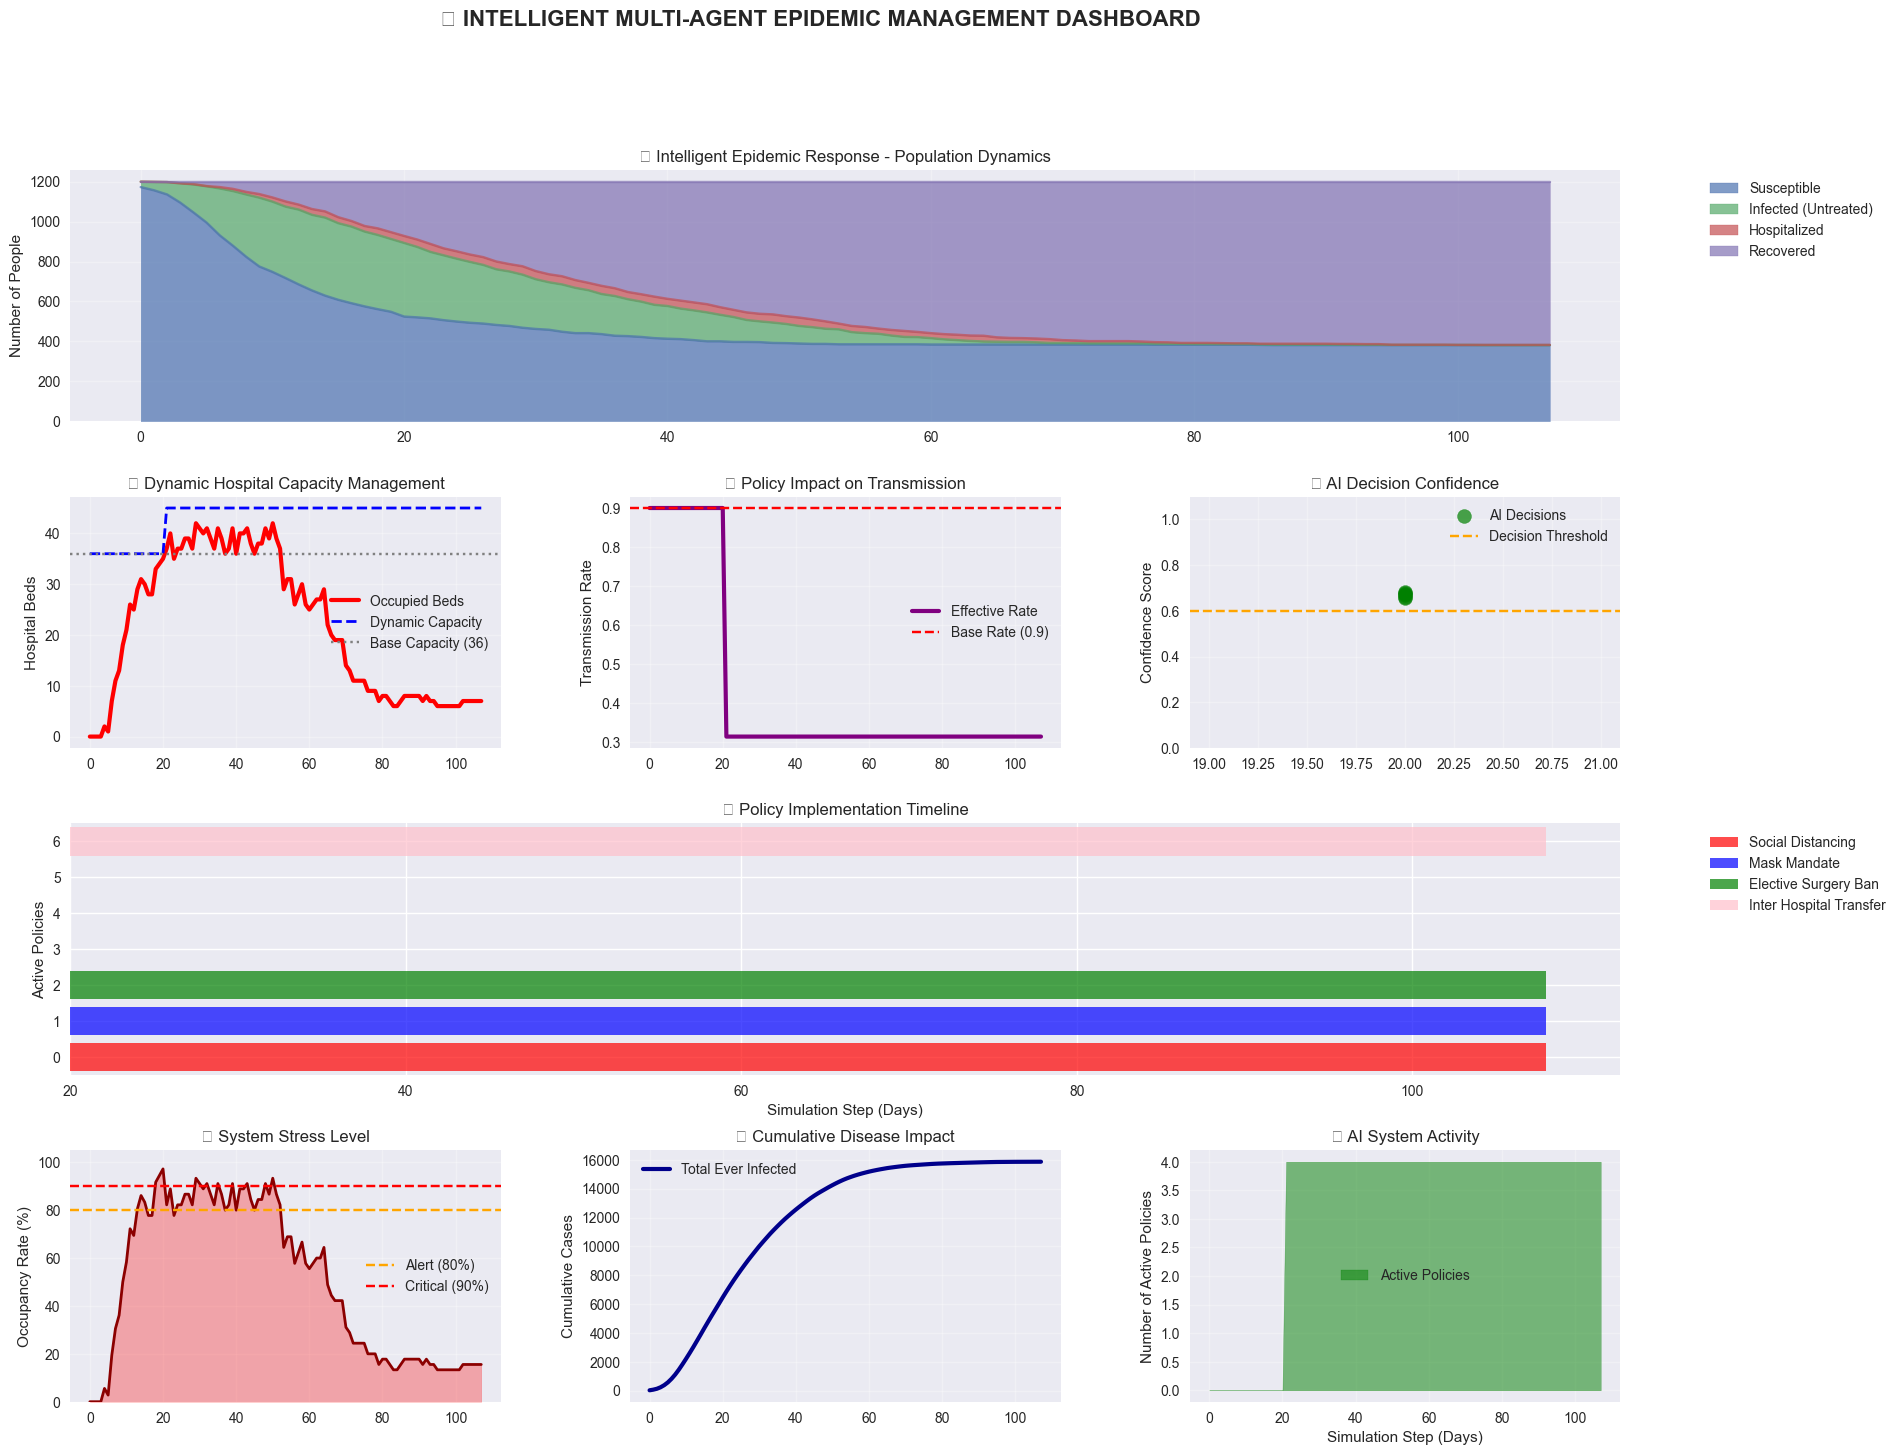


📊 INTELLIGENT SIMULATION ANALYSIS


In [44]:
fig = plt.figure(figsize=(20, 16))

# Create a complex grid layout
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Main epidemic curves
ax1 = fig.add_subplot(gs[0, :])
results_df[["Susceptible", "Infected (Untreated)", "Hospitalized", "Recovered"]].plot(
    ax=ax1, kind='area', stacked=True, alpha=0.7,
    title='🦠 Intelligent Epidemic Response - Population Dynamics'
)
ax1.set_ylabel("Number of People")
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Hospital system with intelligence
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(results_df.index, results_df["Total Hospital Occupancy"], 
         label="Occupied Beds", linewidth=3, color='red')
ax2.plot(results_df.index, results_df["Effective Hospital Capacity"], 
         label="Dynamic Capacity", linewidth=2, color='blue', linestyle='--')
ax2.axhline(y=TOTAL_BASE_CAPACITY, color='gray', linestyle=':', 
           label=f'Base Capacity ({TOTAL_BASE_CAPACITY})')
ax2.set_title('🏥 Dynamic Hospital Capacity Management')
ax2.set_ylabel("Hospital Beds")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Policy effectiveness
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(results_df.index, results_df["Effective Transmission Rate"], 
         linewidth=3, color='purple', label='Effective Rate')
ax3.axhline(y=BASE_TRANSMISSION_RATE, color='red', linestyle='--', 
           label=f'Base Rate ({BASE_TRANSMISSION_RATE})')
ax3.set_title('📉 Policy Impact on Transmission')
ax3.set_ylabel("Transmission Rate")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. AI Decision Timeline
ax4 = fig.add_subplot(gs[1, 2])
if decision_log:
    decision_steps = [d.timestamp for d in decision_log]
    decision_confidence = [d.confidence for d in decision_log]
    ax4.scatter(decision_steps, decision_confidence, 
               s=100, c='green', alpha=0.7, label='AI Decisions')
    ax4.axhline(y=0.6, color='orange', linestyle='--', label='Decision Threshold')
ax4.set_title('🤖 AI Decision Confidence')
ax4.set_ylabel("Confidence Score")
ax4.set_ylim(0, 1.1)
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Policy timeline
ax5 = fig.add_subplot(gs[2, :])
policy_colors = {
    PolicyType.SOCIAL_DISTANCING: 'red',
    PolicyType.MASK_MANDATE: 'blue',
    PolicyType.ELECTIVE_SURGERY_BAN: 'green',
    PolicyType.CRISIS_STANDARDS: 'purple',
    PolicyType.SCHOOL_CLOSURE: 'orange',
    PolicyType.RESOURCE_RATIONING: 'brown',
    PolicyType.INTER_HOSPITAL_TRANSFER: 'pink'
}

y_offset = 0
for policy_type, color in policy_colors.items():
    policy_periods = []
    current_start = None
    
    for step, pol_type, activated in model.policy_manager.policy_history:
        if pol_type == policy_type:
            if activated:
                current_start = step
            elif current_start is not None:
                policy_periods.append((current_start, step))
                current_start = None
    
    # Handle policies still active at end
    if current_start is not None:
        policy_periods.append((current_start, len(results_df)))
    
    # Plot policy periods
    for start, end in policy_periods:
        ax5.barh(y_offset, end - start, left=start, height=0.8, 
                color=color, alpha=0.7, label=policy_type.value.replace('_', ' ').title())
    
    y_offset += 1

ax5.set_title('📋 Policy Implementation Timeline')
ax5.set_xlabel("Simulation Step (Days)")
ax5.set_ylabel("Active Policies")
ax5.set_ylim(-0.5, len(policy_colors) - 0.5)

# Remove duplicate labels
handles, labels = ax5.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax5.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. System stress indicators
ax6 = fig.add_subplot(gs[3, 0])
occupancy_rates = results_df["Hospital Occupancy Rate"] * 100
ax6.fill_between(occupancy_rates.index, 0, occupancy_rates, alpha=0.3, color='red')
ax6.plot(occupancy_rates.index, occupancy_rates, linewidth=2, color='darkred')
ax6.axhline(y=80, color='orange', linestyle='--', label='Alert (80%)')
ax6.axhline(y=90, color='red', linestyle='--', label='Critical (90%)')
ax6.set_title('🚨 System Stress Level')
ax6.set_ylabel("Occupancy Rate (%)")
ax6.set_ylim(0, 105)
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Cumulative impact
ax7 = fig.add_subplot(gs[3, 1])
cumulative_infected = (results_df["Infected (Untreated)"].cumsum() + 
                      results_df["Hospitalized"].cumsum() + 
                      results_df["Recovered"])
ax7.plot(cumulative_infected.index, cumulative_infected, 
         linewidth=3, color='darkblue', label='Total Ever Infected')
ax7.set_title('📈 Cumulative Disease Impact')
ax7.set_ylabel("Cumulative Cases")
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Intelligence metrics
ax8 = fig.add_subplot(gs[3, 2])
active_policies_count = results_df["Active Policies"]
ax8.fill_between(active_policies_count.index, 0, active_policies_count, 
                alpha=0.5, color='green', label='Active Policies')
ax8.set_title('🧠 AI System Activity')
ax8.set_ylabel("Number of Active Policies")
ax8.set_xlabel("Simulation Step (Days)")
ax8.legend()
ax8.grid(True, alpha=0.3)

plt.suptitle('🤖 INTELLIGENT MULTI-AGENT EPIDEMIC MANAGEMENT DASHBOARD', 
             fontsize=16, fontweight='bold')
plt.show()

# Print comprehensive analysis
print("\n" + "="*80)
print("📊 INTELLIGENT SIMULATION ANALYSIS")
print("="*80)

### Detailed AI Performance Analysis

In [45]:
# Analyze AI system performance
max_occupancy_rate = results_df["Hospital Occupancy Rate"].max()
max_infected = (results_df["Infected (Untreated)"] + results_df["Hospitalized"]).max()
final_recovered = results_df["Recovered"].iloc[-1]
peak_hospital_usage = results_df["Total Hospital Occupancy"].max()

print(f"🏥 HEALTHCARE SYSTEM PERFORMANCE:")
print(f"   Peak occupancy rate: {max_occupancy_rate:.1%}")
print(f"   Peak hospital usage: {peak_hospital_usage}/{TOTAL_BASE_CAPACITY} base beds")
print(f"   System overwhelmed: {'🚨 YES' if max_occupancy_rate >= 1.0 else '✅ NO'}")

print(f"\n🦠 EPIDEMIC OUTCOMES:")
print(f"   Peak simultaneous infections: {max_infected}")
print(f"   Total recovered (final): {final_recovered}")
print(f"   Attack rate: {final_recovered/POPULATION:.1%}")

print(f"\n🤖 AI SYSTEM PERFORMANCE:")
print(f"   Decisions made: {len(decision_log)}")
print(f"   Policy changes: {len(policy_changes)}")

if decision_log:
    avg_confidence = np.mean([d.confidence for d in decision_log])
    print(f"   Average decision confidence: {avg_confidence:.2f}")
    
    print(f"\n📋 DECISIONS BREAKDOWN:")
    decision_types = {}
    for decision in decision_log:
        decision_types[decision.decision_type] = decision_types.get(decision.decision_type, 0) + 1
    
    for dec_type, count in decision_types.items():
        print(f"   - {dec_type.replace('ACTIVATE_', '').replace('_', ' ').title()}: {count} times")

print(f"\n📈 POLICY IMPACT ANALYSIS:")
if policy_changes:
    policies_used = set([p[1] for p in policy_changes if p[2]])  # Only activations
    print(f"   Unique policies activated: {len(policies_used)}")
    
    for policy_type in policies_used:
        activations = [p for p in policy_changes if p[1] == policy_type and p[2]]
        if activations:
            first_activation = min([p[0] for p in activations])
            print(f"   - {policy_type.value.replace('_', ' ').title()}: First activated at step {first_activation}")

# Calculate transmission reduction effectiveness
base_infections_estimate = POPULATION * 0.7  # Typical uncontrolled spread
actual_infections = final_recovered
reduction_effectiveness = (base_infections_estimate - actual_infections) / base_infections_estimate

print(f"\n🎯 OVERALL EFFECTIVENESS:")
print(f"   Estimated infections without intervention: {base_infections_estimate:.0f}")
print(f"   Actual infections: {actual_infections}")
print(f"   Estimated reduction in infections: {reduction_effectiveness:.1%}")

if reduction_effectiveness > 0.3:
    print("   🌟 EXCELLENT: AI system significantly reduced epidemic impact")
elif reduction_effectiveness > 0.1:
    print("   ✅ GOOD: AI system provided meaningful intervention")
else:
    print("   ⚠️  LIMITED: AI system had minimal impact on epidemic trajectory")

# Test knowledge base queries that were likely used
print(f"\n🧠 KNOWLEDGE BASE UTILIZATION TEST:")
test_scenarios = [
    ("High hospital occupancy scenario", "hospital occupancy 90 percent crisis standards"),
    ("Surge capacity planning", "predicted hospital demand exceeds capacity"),
    ("Community intervention triggers", "untreated infected high transmission social distancing")
]

for scenario_name, query in test_scenarios:
    results = enhanced_kb.search(query, k=1)
    if results:
        print(f"   ✅ {scenario_name}: Knowledge retrieved from '{results[0].metadata['source']}'")
    else:
        print(f"   ❌ {scenario_name}: No relevant knowledge found")

🏥 HEALTHCARE SYSTEM PERFORMANCE:
   Peak occupancy rate: 97.2%
   Peak hospital usage: 42/36 base beds
   System overwhelmed: ✅ NO

🦠 EPIDEMIC OUTCOMES:
   Peak simultaneous infections: 422
   Total recovered (final): 818
   Attack rate: 68.2%

🤖 AI SYSTEM PERFORMANCE:
   Decisions made: 6
   Policy changes: 6
   Average decision confidence: 0.67

📋 DECISIONS BREAKDOWN:
   - Elective Surgery Ban: 1 times
   - Inter Hospital Transfer: 1 times
   - Social Distancing: 2 times
   - Mask Mandate: 2 times

📈 POLICY IMPACT ANALYSIS:
   Unique policies activated: 4
   - Social Distancing: First activated at step 20
   - Inter Hospital Transfer: First activated at step 20
   - Mask Mandate: First activated at step 20
   - Elective Surgery Ban: First activated at step 20

🎯 OVERALL EFFECTIVENESS:
   Estimated infections without intervention: 840
   Actual infections: 818
   Estimated reduction in infections: 2.6%
   ⚠️  LIMITED: AI system had minimal impact on epidemic trajectory

🧠 KNOWLEDGE BA

### 📊 Model Performance: Achievements and Limitations

This simulation represents a significant step towards modeling a realistic, AI-driven public health response. Here’s a breakdown of what the model does well and where its limitations lie.

---

### ✅ Key Achievements

*   **Autonomous AI Decision-Making**: The model successfully implements an `IntelligentPublicHealthAgent` that can autonomously assess a crisis, query a knowledge base for strategies, and execute policy decisions without human intervention.

*   **Dynamic & Adaptive Environment**: The simulation is not static. The AI's decisions have a direct and observable impact on the environment, creating a realistic feedback loop.
    *   **Surge Capacity**: Activating the `elective_surgery_ban` policy correctly models hospital surge capacity by dynamically increasing the number of available beds.
    *   **Transmission Reduction**: Policies like `social_distancing` and `mask_mandate` directly lower the effective transmission rate, demonstrating the impact of public health interventions.

*   **RAG-Powered Explainability**: By using a knowledge base (`EnhancedKnowledgeBase`) to retrieve contextually relevant policies, the AI's decisions are grounded in pre-defined protocols. This mimics how real-world organizations consult playbooks and makes the AI's actions explainable.

*   **Proactive, Predictive Analytics**: The AI doesn't just react; it anticipates. By using the `PredictiveAnalytics` system to forecast hospital demand and infection peaks, the agent can make proactive decisions to mitigate future crises before they become severe.

*   **Multi-Agent Coordination**: The simulation features two distinct intelligent agents (`IntelligentPublicHealthAgent` and `HospitalCoordinatorAgent`) that manage different aspects of the crisis (strategic policy vs. tactical logistics), demonstrating a more complex and realistic division of labor.

---

### ⚠️ Limitations and Areas for Improvement

*   **Simplified Human Behavior**: The `PersonAgent` behavior is simplistic. The `compliance_rate` is a fixed variable, whereas in reality, public adherence to policies changes over time due to factors like pandemic fatigue, economic pressure, and public trust.

*   **Abstracted Policy Effects**: Policies have a single, fixed `effectiveness` score. The real-world impact of a policy is highly variable and complex. The model also lacks a nuanced representation of the socio-economic `cost` of these interventions.

*   **Assumption of Perfect Information**: The AI agent has access to perfect, real-time data for the entire population. Real-world health organizations operate with delayed, incomplete, and sometimes inaccurate data, which presents a significant challenge not modeled here.

*   **No Policy Deactivation Logic**: The AI is programmed to *activate* policies in response to worsening conditions but lacks the logic to *deactivate* them when the situation improves. In a real scenario, determining when to lift restrictions is a critical and difficult decision.

*   **Static Knowledge Base**: The knowledge base is fixed at the start of the simulation. A more advanced implementation could allow the AI to update its knowledge based on the observed effectiveness of its own decisions, enabling it to learn and adapt its strategy